## Loading a real data

In [2]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [2]:
im_or = cv2.imread("PirabasB_2 - Copy.tif")

In [3]:
im_or.shape, im_or.dtype

((768, 1024, 3), dtype('uint8'))

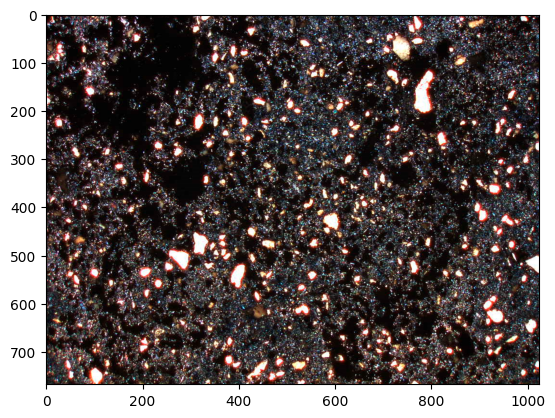

In [4]:
plt.imshow(im_or)

## With a sinthetic data

In [3]:
im_or = cv2.imread("porous_material.tiff")

In [4]:
im_or.shape


(200, 200, 3)

In [8]:
im_or = im_or[:,:,0]

In [13]:
im_or[:50,:50]

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 1, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

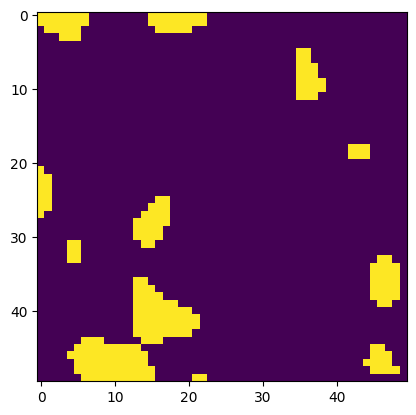

In [14]:
plt.imshow(im_or[:50,:50])

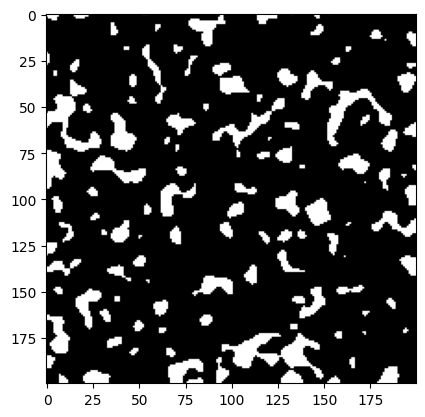

In [11]:
# In this version the pore is represented by the nubmer 1 (white mask/without cmap gray, is the green mask)
plt.imshow(im_or, cmap="gray")

## Processing

In [15]:
im_or = im_or[:, :, 0]

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [16]:
im_or.shape, im_or.dtype

((200, 200), dtype('uint8'))

In [17]:
# # Dividindo a imagem em 4 quadrantes
# height, width = im_or.shape
# half_height, half_width = height // 2, width // 2

# # Quadrantes
# top_left = im_or[:half_height, :half_width]
# top_right = im_or[:half_height, half_width:]
# bottom_left = im_or[half_height:, :half_width]
# bottom_right = im_or[half_height:, half_width:]

# # Verificando as formas dos quadrantes
# print("Top Left Shape:", top_left.shape)
# print("Top Right Shape:", top_right.shape)
# print("Bottom Left Shape:", bottom_left.shape)
# print("Bottom Right Shape:", bottom_right.shape)

In [18]:
##im = bottom_right # A great result 

In [19]:
##im = bottom_left # A great result(runing)

In [20]:
##im = top_left # A great result

In [21]:
##im = top_right

In [22]:
##im.min(), im.max()

In [23]:
##im = (im - im.min())/ (im.max() - im.min()) 

In [24]:
##im.max(), im.min(), im.shape

In [25]:
im = im_or

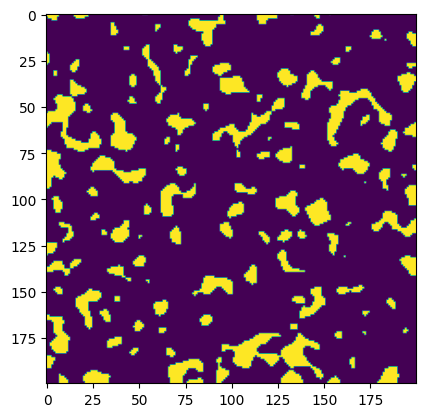

In [26]:
plt.imshow(im)
plt.show()

In [39]:
# Set the pore to be the value 1 # foreground
# This function is to create the binary image to the recognition process work
def create_binary_adjust_1(img):    
    import cv2
    # Convert the image to grayscale
    #gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply a threshold to the grayscale image
    #threshold_value = 25 # The ideal value to the sample pirabas 2
    thresold_value = 0 
    max_value = 1
    #ret, binary = cv2.threshold(img, thresold_value, max_value, cv2.THRESH_BINARY_INV) # use this to pirabas 2
    ret, binary = cv2.threshold(img, thresold_value, max_value, cv2.THRESH_BINARY)
    return binary
# That's my case

In [43]:
binary_image = create_binary_adjust_1(im)

# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

In [44]:
binary_image.shape, binary_image.min(), binary_image.max()

((200, 200), 0, 1)

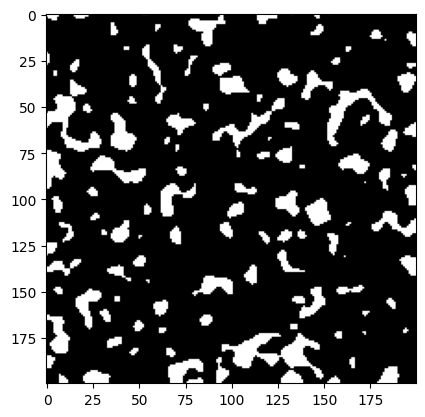

In [45]:
plt.imshow(binary_image, cmap='gray')

In [46]:
num_labels, labeled_image.shape

(127, (200, 200))

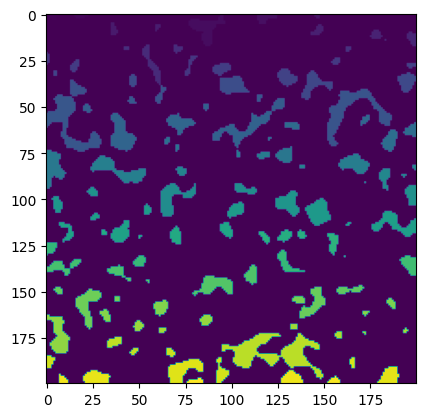

In [47]:
plt.imshow(labeled_image)

## save the segmented regions

In [48]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)


Random number: 16


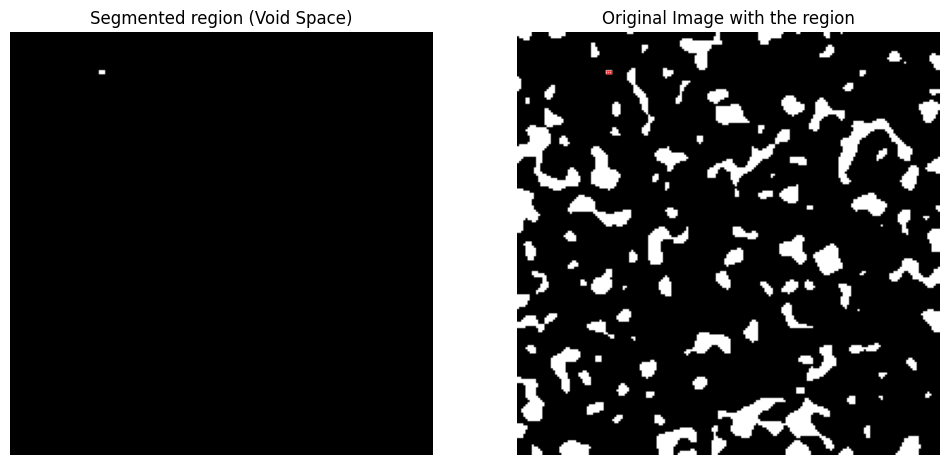

In [49]:
import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

## Apply the cluster tecnique: k means

In [50]:
# The number of pixels to consider a pore

pore_number = 36 # This is the ideal cluster to the shape (384, 512) pirabasb_2

In [51]:
pore_number

36

In [83]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours, label, regionprops

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Encontrar os contornos de cada cluster
    contornos_por_cluster = []
    for i in range(num_clusters):
        mask = clustered_region == (i + 1)  # Criar uma máscara para o cluster atual
        contornos = find_contours(mask, 0.5)  # Encontrar os contornos do cluster atual
        contornos_por_cluster.append(contornos)

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers, contornos_por_cluster

def calculate_aspect_ratios(contornos_por_cluster):
    aspect_ratios = []
    for contornos in contornos_por_cluster:
        for contorno in contornos:
            if len(contorno) < 5:
                continue
            # Encontrar as propriedades da região contornada
            x_min, y_min = np.min(contorno, axis=0)
            x_max, y_max = np.max(contorno, axis=0)
            major_axis_length = y_max - y_min
            minor_axis_length = x_max - x_min
            # Calcular a razão de aspecto
            if major_axis_length > 0:  # Evitar divisão por zero
                aspect_ratio = minor_axis_length / major_axis_length
            else:
                aspect_ratio = 0
            aspect_ratios.append(aspect_ratio)
    return aspect_ratios






# 
# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
#areas_cluster_kmeans = []
contour_per_cluster = []
ratio_of_aspect_cluster_kmeans = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans, contornos_por_cluster = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)
    
    # Calcular as razões de aspecto dos clusters
    aspect_ratios_kmeans = calculate_aspect_ratios(contornos_por_cluster)
    ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)
    
    # Calcular as áreas dos clusters
    #areas_kmeans = calculate_areas(clustered_region_kmeans)
    #areas_cluster_kmeans.append(areas_kmeans)
    
    # Armazenar os contornos dos clusters
    contour_per_cluster.append(contornos_por_cluster)

# Exemplo de uso dos resultados
for i, aspect_ratios in enumerate(ratio_of_aspect_cluster_kmeans):
    print(f'Região {i+1}: Razões de aspecto dos clusters = {aspect_ratios}')

C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when

Região 1: Razões de aspecto dos clusters = [0.5384615384615384]
Região 2: Razões de aspecto dos clusters = [0.3125]
Região 3: Razões de aspecto dos clusters = [0.16666666666666666]
Região 4: Razões de aspecto dos clusters = [1.1666666666666667, 0.875, 0.875, 0.9285714285714286]
Região 5: Razões de aspecto dos clusters = [0.4583333333333333]
Região 6: Razões de aspecto dos clusters = []
Região 7: Razões de aspecto dos clusters = [0.8333333333333334]
Região 8: Razões de aspecto dos clusters = []
Região 9: Razões de aspecto dos clusters = [1.75]
Região 10: Razões de aspecto dos clusters = [1.3333333333333333]
Região 11: Razões de aspecto dos clusters = [0.8571428571428571]
Região 12: Razões de aspecto dos clusters = [0.7142857142857143]
Região 13: Razões de aspecto dos clusters = [1.7777777777777777]
Região 14: Razões de aspecto dos clusters = [1.0]
Região 15: Razões de aspecto dos clusters = [1.7142857142857142, 1.8333333333333333]
Região 16: Razões de aspecto dos clusters = [1.0]
Região

In [79]:
len(resultados_kmeans), len(ratio_of_aspect_cluster_kmeans)

(127, 127)

In [92]:
ratio_of_aspect_cluster_kmeans[119], len(contour_per_cluster[119])

([2.0], 1)

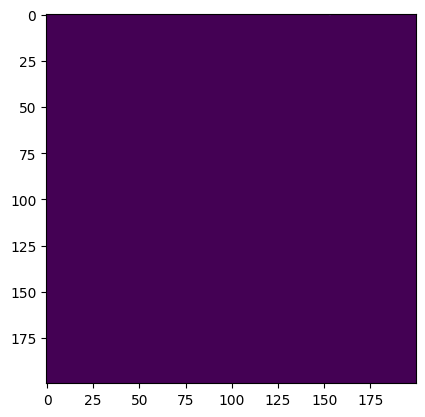

In [94]:
plt.imshow(resultados_kmeans[7])

In [97]:
# generate the trained data
import numpy as np

# Define the size of the vector
size = 1000  # Example size of the vector

# Generate the vector with values between 0 and 2
feature_aspect_ratio = np.random.uniform(low=0, high=2, size=size)

In [98]:
len(feature_aspect_ratio)

1000

In [102]:
type_pore = []
for i in range(0,len(feature_aspect_ratio)):
    if feature_aspect_ratio[i] < 1:
        type_pore_temp = 1 
    elif feature_aspect_ratio[i] == 1:
        type_pore_temp = 2
    elif feature_aspect_ratio[i] > 1:
        type_pore_temp = 3
    type_pore.append(type_pore_temp)

In [104]:
len(type_pore), len(feature_aspect_ratio)

(1000, 1000)

In [107]:
# Checking if the data to train the model is correct
type_pore[0], feature_aspect_ratio[0]

(3, 1.7066144929740013)